Successfully loaded feature dataset with shape: (1364, 17)
   EEG_Delta_Mean  EEG_Theta_Mean  EEG_Alpha_Mean  EEG_Beta_Mean  \
0        0.239537        0.176614        0.414501       0.267745   
1        0.725022        0.417921        0.597913       0.326772   
2        0.842528        0.515361        0.674078       0.363511   
3        0.843536        0.521588        0.717120       0.298959   
4        0.797471        0.449036        0.638049       0.308217   

   EEG_Gamma_Mean  EEG_Delta_Var  EEG_Theta_Var  EEG_Alpha_Var  EEG_Beta_Var  \
0       -0.207820       0.200958       0.241049       0.345318      0.510831   
1       -0.053515       0.170056       0.318389       0.329053      0.413482   
2       -0.104016       0.188123       0.245929       0.214382      0.407514   
3       -0.142325       0.284534       0.166374       0.224325      0.441674   
4       -0.156758       0.119216       0.119656       0.159670      0.426629   

   EEG_Gamma_Var  EEG_Theta_Alpha_Ratio  EEG_Theta_

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


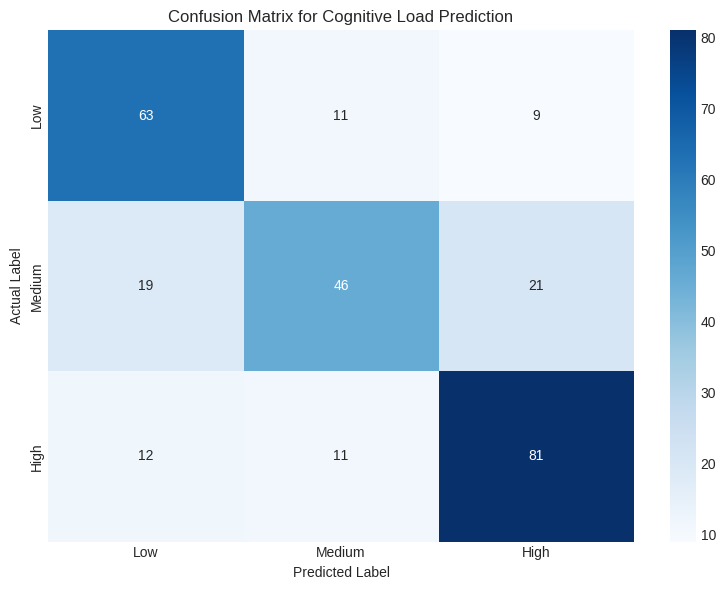

Saved to /content/drive/MyDrive/project/models/lgbm_model.pkl
/content/drive/MyDrive/project/models/lgbm_model.pkl


In [14]:
import pandas as pd
import lightgbm as lgb
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration ---
PROCESSED_DATA_DIR = '/content/drive/MyDrive/project/data/feature_dt'
MODELS_DIR = '/content/drive/MyDrive/project/models'
INPUT_FILE = os.path.join(PROCESSED_DATA_DIR, 'features_dataset.csv')
MODEL_OUTPUT_FILE = os.path.join(MODELS_DIR, 'lgbm_model.pkl')

# Create the models directory if it doesn't exist
os.makedirs(MODELS_DIR, exist_ok=True)

# --- Load the feature dataset ---
try:
    features_df = pd.read_csv(INPUT_FILE)
    print(f"Successfully loaded feature dataset with shape: {features_df.shape}")
except FileNotFoundError:
    print(f"Error: Input file not found at {INPUT_FILE}")
    print("Please run the '02_feature_engineering.ipynb' notebook first.")
    exit()

# --- Prepare Data for Modeling ---
# Define features (X) and target (y)
X = features_df.drop(columns=['Participant', 'TaskKey', 'CognitiveLoad'])
y = features_df['CognitiveLoad']

# print(features_df.head())
# Split data into 80% for training and 20% for testing, ensuring class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Feature Scaling ---
# Scale features to have zero mean and unit variance for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X.head(), "hello")

print(f"Data split and scaled. Training set size: {X_train_scaled.shape[0]}, Test set size: {X_test_scaled.shape[0]}")
print("-" * 50)

# --- Train the LightGBM Model ---
print("Training LightGBM model...")
lgbm = lgb.LGBMClassifier(random_state=42)
lgbm.fit(X_train_scaled, y_train)

# --- Evaluate the Model ---
print("Evaluating model performance...")
y_pred = lgbm.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=['Low Load', 'Medium Load', 'High Load'])

print(f"\nLightGBM Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)
print("-" * 50)

# --- Visualize the Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.title('Confusion Matrix for Cognitive Load Prediction')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


# --- Save the Trained Model and Scaler ---
# We save both the model and the scaler. The scaler is needed to process
# any new data before making predictions.
model_payload = {
    'model': lgbm,
    'scaler': scaler
}
# joblib.dump(model_payload, MODEL_OUTPUT_FILE)
# print(f"Trained model and scaler saved successfully to: {MODEL_OUTPUT_FILE}")
try:
    joblib.dump(model_payload, MODEL_OUTPUT_FILE)
    print(f"Saved to {MODEL_OUTPUT_FILE}")
    print(MODEL_OUTPUT_FILE)
except Exception as e:
    print("Error while saving:", e)
